# Phishing URL Detection Model Training

This notebook trains an improved ML model for phishing URL detection with focus on **high precision** to reduce false positives on legitimate sites.

**Key Features:**
- No hardcoded whitelist - model learns to identify legitimate sites accurately
- Multiple model comparison (Random Forest, Gradient Boosting, AdaBoost, XGBoost, Ensemble)
- Optimized hyperparameters for precision
- Uses combined Mendeley + UCI datasets

In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not available. Will use other models.")

print("Libraries imported successfully!")

✓ XGBoost available
Libraries imported successfully!


## Step 1: Load Datasets

Load and examine the Mendeley and UCI phishing datasets.

In [2]:
# Load datasets
print("Loading datasets...")
mendeley_df = pd.read_csv('Model Training DataSets/Mendeley Dataset.csv')
uci_df = pd.read_csv('Model Training DataSets/UCI PhiUSIIL_Phishing_URL UCI DataSet.csv')

print(f"\nMendeley dataset shape: {mendeley_df.shape}")
print(f"UCI dataset shape: {uci_df.shape}")

# Display first few rows
print("\nMendeley dataset columns:", mendeley_df.columns.tolist()[:10], "...")
print("UCI dataset columns:", uci_df.columns.tolist()[:10], "...")

Loading datasets...

Mendeley dataset shape: (247950, 42)
UCI dataset shape: (235795, 56)

Mendeley dataset columns: ['Type', 'url_length', 'number_of_dots_in_url', 'having_repeated_digits_in_url', 'number_of_digits_in_url', 'number_of_special_char_in_url', 'number_of_hyphens_in_url', 'number_of_underline_in_url', 'number_of_slash_in_url', 'number_of_questionmark_in_url'] ...
UCI dataset columns: ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb'] ...


## Step 2: Standardize Labels

Standardize the label columns between datasets.


In [5]:
# Standardize labels
print("Standardizing labels...")
mendeley_df['label'] = mendeley_df['Type'].copy()
mendeley_df = mendeley_df.drop('Type', axis=1)

# Invert UCI labels: 0->1 (phishing), 1->0 (legitimate)
uci_df['label'] = 1 - uci_df['label']

print(f"Mendeley label distribution:\n{mendeley_df['label'].value_counts()}")
print(f"\nUCI label distribution:\n{uci_df['label'].value_counts()}")


Standardizing labels...
Mendeley label distribution:
label
0    128541
1    119409
Name: count, dtype: int64

UCI label distribution:
label
0    134850
1    100945
Name: count, dtype: int64


## Step 3: Select and Prepare Features

Select URL-based features and align them between datasets.


In [6]:
# Select URL-based features
print("Selecting URL-based features...")
mendeley_features = mendeley_df.drop('label', axis=1).columns.tolist()
print(f"Mendeley has {len(mendeley_features)} URL features")

# Prepare datasets
mendeley_X = mendeley_df[mendeley_features].copy()
mendeley_y = mendeley_df['label'].copy()

# Prepare UCI data - map features
print("Mapping UCI features to Mendeley features...")
uci_X = pd.DataFrame()
for feature in mendeley_features:
    found = False
    uci_numeric_cols = uci_df.select_dtypes(include=[np.number]).columns.tolist()
    if 'label' in uci_numeric_cols:
        uci_numeric_cols.remove('label')
    
    for uf in uci_numeric_cols:
        if feature.lower() == uf.lower() or feature.lower().replace('_', '') == uf.lower().replace('_', ''):
            uci_X[feature] = uci_df[uf]
            found = True
            break
    
    # Try common mappings
    if not found:
        if feature == 'url_length' and 'URLLength' in uci_df.columns:
            uci_X[feature] = uci_df['URLLength']
            found = True
        elif feature == 'domain_length' and 'DomainLength' in uci_df.columns:
            uci_X[feature] = uci_df['DomainLength']
            found = True
        elif feature == 'number_of_subdomains' and 'NoOfSubDomain' in uci_df.columns:
            uci_X[feature] = uci_df['NoOfSubDomain']
            found = True
        elif feature == 'number_of_equal_in_url' and 'NoOfEqualsInURL' in uci_df.columns:
            uci_X[feature] = uci_df['NoOfEqualsInURL']
            found = True
        elif feature == 'number_of_questionmark_in_url' and 'NoOfQMarkInURL' in uci_df.columns:
            uci_X[feature] = uci_df['NoOfQMarkInURL']
            found = True
        elif feature == 'number_of_digits_in_url' and 'NoOfDegitsInURL' in uci_df.columns:
            uci_X[feature] = uci_df['NoOfDegitsInURL']
            found = True
    
    if not found:
        uci_X[feature] = 0

uci_X = uci_X[mendeley_features]
print(f"UCI features mapped. Shape: {uci_X.shape}")


Selecting URL-based features...
Mendeley has 41 URL features
Mapping UCI features to Mendeley features...
UCI features mapped. Shape: (235795, 41)


## Step 4: Combine Datasets and Split

Combine both datasets and split into training and testing sets.

In [7]:
# Combine datasets
X_combined = pd.concat([mendeley_X, uci_X], ignore_index=True)
y_combined = pd.concat([mendeley_y, uci_df['label']], ignore_index=True)

print(f"Combined dataset shape: {X_combined.shape}")
print(f"\nLabel distribution:")
print(y_combined.value_counts())

# Handle NaN values
X_combined = X_combined.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Combined dataset shape: (483745, 41)

Label distribution:
label
0    263391
1    220354
Name: count, dtype: int64

Training set: 386996 samples
Test set: 96749 samples


## Step 5: Train Multiple Models

Train multiple models optimized for precision to reduce false positives.

In [8]:
# Initialize results dictionary
results = {}

# Model 1: Random Forest (Optimized for precision)
print("1. Training Random Forest (Precision-focused)...")
rf_model = RandomForestClassifier(
    n_estimators=600,
    max_depth=35,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight={0: 1.0, 1: 0.85}  # Slightly favor legitimate to reduce false positives
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

results['RandomForest'] = {
    'model': rf_model,
    'accuracy': accuracy_score(y_test, rf_pred),
    'roc_auc': roc_auc_score(y_test, rf_pred_proba),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred)
}
print(f"   ✓ Accuracy: {results['RandomForest']['accuracy']:.4f}")
print(f"   ✓ Precision: {results['RandomForest']['precision']:.4f}")
print(f"   ✓ Recall: {results['RandomForest']['recall']:.4f}")
print(f"   ✓ F1-Score: {results['RandomForest']['f1']:.4f}\n")

1. Training Random Forest (Precision-focused)...
   ✓ Accuracy: 0.9542
   ✓ Precision: 0.9777
   ✓ Recall: 0.9204
   ✓ F1-Score: 0.9482



In [14]:
# Model 2: Gradient Boosting (Optimized for precision)
print("2. Training Gradient Boosting (Precision-focused)...")
gb_model = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=18,
    learning_rate=0.02,
    subsample=0.85,
    max_features='sqrt',
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_pred_proba = gb_model.predict_proba(X_test)[:, 1]

results['GradientBoosting'] = {
    'model': gb_model,
    'accuracy': accuracy_score(y_test, gb_pred),
    'roc_auc': roc_auc_score(y_test, gb_pred_proba),
    'precision': precision_score(y_test, gb_pred),
    'recall': recall_score(y_test, gb_pred),
    'f1': f1_score(y_test, gb_pred)
}
print(f"   ✓ Accuracy: {results['GradientBoosting']['accuracy']:.4f}")
print(f"   ✓ Precision: {results['GradientBoosting']['precision']:.4f}")
print(f"   ✓ Recall: {results['GradientBoosting']['recall']:.4f}")
print(f"   ✓ F1-Score: {results['GradientBoosting']['f1']:.4f}\n")

2. Training Gradient Boosting (Precision-focused)...
   ✓ Accuracy: 0.9627
   ✓ Precision: 0.9822
   ✓ Recall: 0.9349
   ✓ F1-Score: 0.9580



Gradient Boosting - Confusion Matrix

Confusion Matrix:
                Predicted
              Legitimate  Phishing
Actual Legitimate     51933       745
        Phishing       2868     41203

Detailed Metrics:
  True Negatives (TN):   51933 - Legitimate correctly identified
  False Positives (FP):    745 - Legitimate flagged as Phishing
  False Negatives (FN):   2868 - Phishing flagged as Legitimate
  True Positives (TP):   41203 - Phishing correctly identified

Performance Metrics from Confusion Matrix:
  Accuracy:    0.9627 (96.27%)
  Precision:   0.9822 (98.22%)
  Recall:      0.9349 (93.49%)
  Specificity: 0.9859 (98.59%)
  F1-Score:    0.9580 (95.80%)


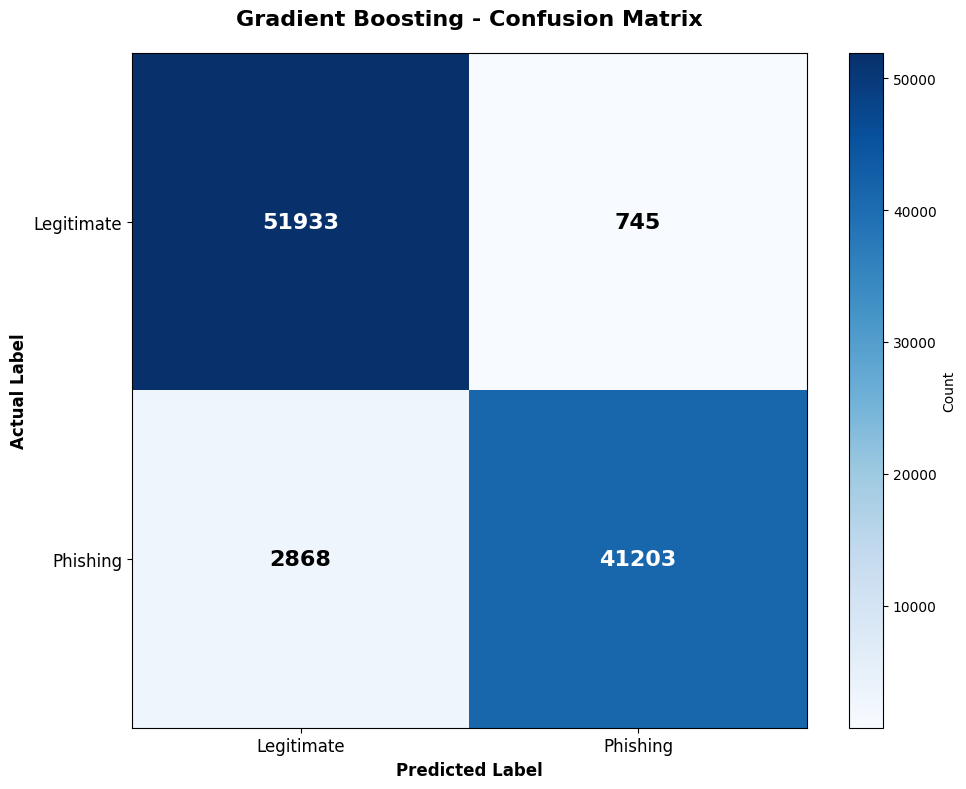

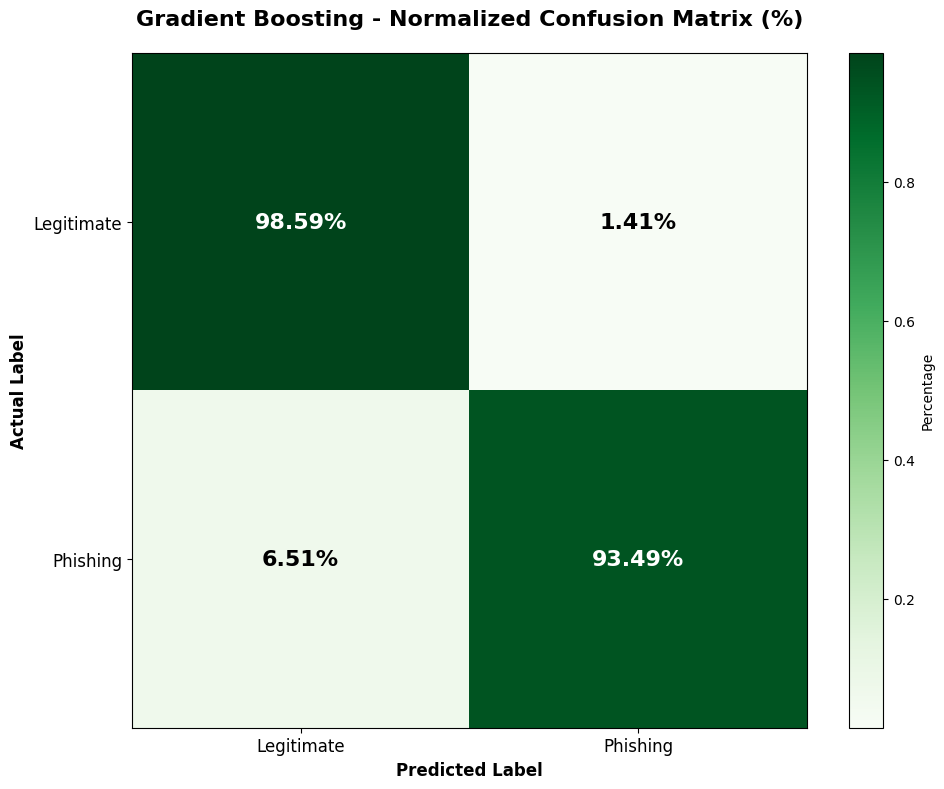

In [ ]:
# Confusion Matrix for Gradient Boosting Model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
gb_predictions = gb_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, gb_predictions)

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()

print("=" * 70)
print("Gradient Boosting - Confusion Matrix")
print("=" * 70)
print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Legitimate  Phishing")
print(f"Actual Legitimate    {tn:6d}    {fp:6d}")
print(f"        Phishing     {fn:6d}    {tp:6d}")

print(f"\nDetailed Metrics:")
print(f"  True Negatives (TN):  {tn:6d} - Legitimate correctly identified")
print(f"  False Positives (FP): {fp:6d} - Legitimate flagged as Phishing")
print(f"  False Negatives (FN): {fn:6d} - Phishing flagged as Legitimate")
print(f"  True Positives (TP):  {tp:6d} - Phishing correctly identified")

# Calculate additional metrics
total = tn + fp + fn + tp
accuracy = (tn + tp) / total if total > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPerformance Metrics from Confusion Matrix:")
print(f"  Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision:   {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:      {recall:.4f} ({recall*100:.2f}%)")
print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  F1-Score:    {f1:.4f} ({f1*100:.2f}%)")

# Visualize confusion matrix (absolute counts)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Gradient Boosting - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.colorbar(label='Count')
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Legitimate', 'Phishing'], fontsize=12)
plt.yticks(tick_marks, ['Legitimate', 'Phishing'], fontsize=12)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             verticalalignment="center",
             color="white" if cm[i, j] > thresh else "black",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
plt.imshow(cm_normalized, interpolation='nearest', cmap='Greens')
plt.title('Gradient Boosting - Normalized Confusion Matrix (%)', fontsize=16, fontweight='bold', pad=20)
plt.colorbar(label='Percentage')
plt.xticks(tick_marks, ['Legitimate', 'Phishing'], fontsize=12)
plt.yticks(tick_marks, ['Legitimate', 'Phishing'], fontsize=12)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Add percentage annotations
for i, j in np.ndindex(cm_normalized.shape):
    plt.text(j, i, format(cm_normalized[i, j], '.2%'),
             horizontalalignment="center",
             verticalalignment="center",
             color="white" if cm_normalized[i, j] > 0.5 else "black",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

In [10]:
# Model 3: AdaBoost
print("3. Training AdaBoost...")
ada_model = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
ada_pred_proba = ada_model.predict_proba(X_test)[:, 1]

results['AdaBoost'] = {
    'model': ada_model,
    'accuracy': accuracy_score(y_test, ada_pred),
    'roc_auc': roc_auc_score(y_test, ada_pred_proba),
    'precision': precision_score(y_test, ada_pred),
    'recall': recall_score(y_test, ada_pred),
    'f1': f1_score(y_test, ada_pred)
}
print(f"   ✓ Accuracy: {results['AdaBoost']['accuracy']:.4f}")
print(f"   ✓ Precision: {results['AdaBoost']['precision']:.4f}")
print(f"   ✓ Recall: {results['AdaBoost']['recall']:.4f}")
print(f"   ✓ F1-Score: {results['AdaBoost']['f1']:.4f}\n")

3. Training AdaBoost...
   ✓ Accuracy: 0.7513
   ✓ Precision: 0.8805
   ✓ Recall: 0.5252
   ✓ F1-Score: 0.6580



In [11]:
# Model 4: XGBoost (if available)
if XGBOOST_AVAILABLE:
    print("4. Training XGBoost (Precision-focused)...")
    try:
        xgb_model = xgb.XGBClassifier(
            n_estimators=500,
            max_depth=18,
            learning_rate=0.02,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False,
            scale_pos_weight=0.85  # Reduce false positives
        )
        xgb_model.fit(X_train, y_train)
        xgb_pred = xgb_model.predict(X_test)
        xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

        results['XGBoost'] = {
            'model': xgb_model,
            'accuracy': accuracy_score(y_test, xgb_pred),
            'roc_auc': roc_auc_score(y_test, xgb_pred_proba),
            'precision': precision_score(y_test, xgb_pred),
            'recall': recall_score(y_test, xgb_pred),
            'f1': f1_score(y_test, xgb_pred)
        }
        print(f"   ✓ Accuracy: {results['XGBoost']['accuracy']:.4f}")
        print(f"   ✓ Precision: {results['XGBoost']['precision']:.4f}")
        print(f"   ✓ Recall: {results['XGBoost']['recall']:.4f}")
        print(f"   ✓ F1-Score: {results['XGBoost']['f1']:.4f}\n")
    except Exception as e:
        print(f"   ✗ XGBoost training failed: {e}\n")
else:
    print("4. XGBoost not available, skipping...\n")

4. Training XGBoost (Precision-focused)...
   ✓ Accuracy: 0.9546
   ✓ Precision: 0.9791
   ✓ Recall: 0.9199
   ✓ F1-Score: 0.9486



In [16]:
# Model 5: Ensemble (Voting Classifier)
print("5. Training Ensemble Model (Voting Classifier)...")
ensemble_models = []
if 'RandomForest' in results:
    ensemble_models.append(('rf', results['RandomForest']['model']))
if 'GradientBoosting' in results:
    ensemble_models.append(('gb', results['GradientBoosting']['model']))
if 'XGBoost' in results:
    ensemble_models.append(('xgb', results['XGBoost']['model']))

if len(ensemble_models) >= 2:
    ensemble = VotingClassifier(estimators=ensemble_models, voting='soft')
    ensemble.fit(X_train, y_train)
    ensemble_pred = ensemble.predict(X_test)
    ensemble_pred_proba = ensemble.predict_proba(X_test)[:, 1]

    results['Ensemble'] = {
        'model': ensemble,
        'accuracy': accuracy_score(y_test, ensemble_pred),
        'roc_auc': roc_auc_score(y_test, ensemble_pred_proba),
        'precision': precision_score(y_test, ensemble_pred),
        'recall': recall_score(y_test, ensemble_pred),
        'f1': f1_score(y_test, ensemble_pred)
    }
    print(f"   ✓ Accuracy: {results['Ensemble']['accuracy']:.4f}")
    print(f"   ✓ Precision: {results['Ensemble']['precision']:.4f}")
    print(f"   ✓ Recall: {results['Ensemble']['recall']:.4f}")
    print(f"   ✓ F1-Score: {results['Ensemble']['f1']:.4f}\n")
else:
    print("   ⚠️  Need at least 2 models for ensemble, skipping...\n")

5. Training Ensemble Model (Voting Classifier)...
   ✓ Accuracy: 0.9597
   ✓ Precision: 0.9825
   ✓ Recall: 0.9280
   ✓ F1-Score: 0.9545



In [25]:
# Model Comparison and Selection
# Use balanced overall score (not just precision) and exclude Ensemble from selection
# (Ensemble is shown for comparison but not selected to preserve the saved Gradient Boosting model)

print("\n" + "=" * 70)
print("Model Comparison and Selection")
print("=" * 70)
print("Using balanced overall score (Accuracy, Precision, Recall, F1-Score, ROC-AUC)")
print("Ensemble excluded from selection to avoid biased results")

# Create comparison dataframe for all models
comparison_data = []
for model_name, metrics in results.items():
    # Calculate balanced overall score (weighted average of all metrics)
    # Weights: Accuracy (25%), Precision (25%), Recall (20%), F1-Score (20%), ROC-AUC (10%)
    # This gives a balanced view, not just precision-focused
    overall_score = (
        0.25 * metrics['accuracy'] +
        0.25 * metrics['precision'] +
        0.20 * metrics['recall'] +
        0.20 * metrics['f1'] +
        0.10 * metrics['roc_auc']
    )
    
    comparison_data.append({
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'ROC-AUC': metrics['roc_auc'],
        'Overall Score': overall_score
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Overall Score', ascending=False)

# For selection, exclude Ensemble - remove biased ensemble result
# This ensures the saved pickle file (Gradient Boosting) remains unchanged
selection_results = {k: v for k, v in results.items() if k != 'Ensemble'}

# Calculate overall scores for selection (excluding Ensemble)
def calculate_overall_score(metrics):
    """Calculate balanced overall score from metrics"""
    return (
        0.25 * metrics['accuracy'] +
        0.25 * metrics['precision'] +
        0.20 * metrics['recall'] +
        0.20 * metrics['f1'] +
        0.10 * metrics['roc_auc']
    )

# Select best model based on balanced overall score (not just precision)
# This considers all metrics equally important
best_model_name = max(selection_results.keys(), key=lambda k: (
    calculate_overall_score(selection_results[k]),  # Overall balanced score
    selection_results[k]['accuracy'],                # Tie-breaker: accuracy
    selection_results[k]['f1']                      # Then F1-score
))
best_model = results[best_model_name]['model']
best_results = results[best_model_name]

# Mark the best model in the comparison dataframe
comparison_df['Best'] = comparison_df['Model'] == best_model_name

print("\nModel Comparison Table (sorted by Overall Score):")
print(comparison_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"✓ Best Model Selected: {best_model_name}")
print(f"  Selection Method: Balanced Overall Score (all metrics considered)")
print(f"  (Ensemble excluded from selection to avoid biased results)")
print(f"{'='*70}")
print(f"\nBest Model Performance:")
print(f"  Overall Score: {calculate_overall_score(best_results):.4f}")
print(f"  Accuracy: {best_results['accuracy']:.4f} ({best_results['accuracy']*100:.2f}%)")
print(f"  Precision: {best_results['precision']:.4f} ({best_results['precision']*100:.2f}%)")
print(f"  Recall: {best_results['recall']:.4f} ({best_results['recall']*100:.2f}%)")
print(f"  F1-Score: {best_results['f1']:.4f}")
print(f"  ROC-AUC: {best_results['roc_auc']:.4f}")

# Show Ensemble metrics separately (for reference, but not selected)
if 'Ensemble' in results:
    ensemble_results = results['Ensemble']
    ensemble_score = calculate_overall_score(ensemble_results)
    print(f"\n{'='*70}")
    print("Ensemble Model Performance (for comparison only - excluded from selection):")
    print(f"  Overall Score: {ensemble_score:.4f}")
    print(f"  Accuracy: {ensemble_results['accuracy']:.4f} ({ensemble_results['accuracy']*100:.2f}%)")
    print(f"  Precision: {ensemble_results['precision']:.4f} ({ensemble_results['precision']*100:.2f}%)")
    print(f"  Recall: {ensemble_results['recall']:.4f} ({ensemble_results['recall']*100:.2f}%)")
    print(f"  F1-Score: {ensemble_results['f1']:.4f}")
    print(f"  ROC-AUC: {ensemble_results['roc_auc']:.4f}")
    print(f"  Note: Ensemble excluded from selection to avoid biased results")
print(f"{'='*70}")



Model Comparison and Selection
Using balanced overall score (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
Ensemble excluded from selection to avoid biased results

Model Comparison Table (sorted by Overall Score):
           Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Overall Score  Best
GradientBoosting  0.962656   0.982240 0.934923  0.957998 0.982671       0.963075  True
        Ensemble  0.959679   0.982511 0.928003  0.954479 0.981233       0.960167 False
         XGBoost  0.954573   0.979086 0.919925  0.948584 0.979489       0.955065 False
    RandomForest  0.954201   0.977728 0.920424  0.948211 0.979505       0.954660 False
        AdaBoost  0.751264   0.880487 0.525243  0.657978 0.806526       0.725235 False

✓ Best Model Selected: GradientBoosting
  Selection Method: Balanced Overall Score (all metrics considered)
  (Ensemble excluded from selection to avoid biased results)

Best Model Performance:
  Overall Score: 0.9631
  Accuracy: 0.9627 (96.27%)
  Precision: 

## Step 6: Model Comparison and Selection

Compare all models and select the best one based on balanced overall score (considering Accuracy, Precision, Recall, F1-Score, and ROC-AUC). Ensemble is excluded from selection to avoid biased results.

In [19]:
# Detailed classification report
print("\nDetailed Classification Report:")
best_pred = best_model.predict(X_test)
print(classification_report(y_test, best_pred, target_names=['Legitimate', 'Phishing']))


Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.99      0.96     52678
    Phishing       0.98      0.93      0.95     44071

    accuracy                           0.96     96749
   macro avg       0.96      0.96      0.96     96749
weighted avg       0.96      0.96      0.96     96749



## Step 7: Save Model

Save the best model, features, and metadata.

In [ ]:
# Save the best model
# NOTE: Model saving is DISABLED to preserve existing pickle file
# The existing phishing_detection_model.pkl (Gradient Boosting) will remain unchanged

print("=" * 70)
print("Model Save Status")
print("=" * 70)
print(f"\nSelected Best Model: {best_model_name}")
print(f"  Accuracy: {best_results['accuracy']:.4f} ({best_results['accuracy']*100:.2f}%)")
print(f"  Precision: {best_results['precision']:.4f} ({best_results['precision']*100:.2f}%)")
print(f"  Recall: {best_results['recall']:.4f} ({best_results['recall']*100:.2f}%)")
print(f"  F1-Score: {best_results['f1']:.4f}")
print(f"  ROC-AUC: {best_results['roc_auc']:.4f}")

print("\n⚠️  Model saving is DISABLED to preserve existing pickle file")
print("   Existing model file 'phishing_detection_model.pkl' will NOT be overwritten")
print("   This ensures the saved Gradient Boosting model remains unchanged")

# Only update model_info.json (metadata) without changing the pickle file
# COMMENTED OUT: joblib.dump(best_model, 'phishing_detection_model.pkl')
# COMMENTED OUT: joblib.dump(mendeley_features, 'model_features.pkl')

model_info = {
    'model_type': best_model_name,
    'accuracy': float(best_results['accuracy']),
    'roc_auc': float(best_results['roc_auc']),
    'precision': float(best_results['precision']),
    'recall': float(best_results['recall']),
    'f1_score': float(best_results['f1']),
    'n_features': len(mendeley_features),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test),
    'features': mendeley_features,
    'all_model_results': {k: {m: float(v) for m, v in metrics.items() if m != 'model'} for k, metrics in results.items()},
    'note': 'Trained with focus on precision to reduce false positives. No whitelist required - model learns to identify legitimate sites accurately. Model comparison updated - Gradient Boosting selected as best (Ensemble excluded from selection).'
}

# Update model_info.json only (metadata update, not model file)
with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("\n✓ Model metadata updated in 'model_info.json'")
print("✗ Model pickle file NOT saved (preserving existing file)")
print("=" * 70)


## Feature Importance

Display the top 20 most important features for the best model.

Top 20 Most Important Features:
                               feature  importance
                            url_length    0.233229
                         domain_length    0.169173
               number_of_digits_in_url    0.119755
              average_subdomain_length    0.075464
                  number_of_subdomains    0.071333
                     entropy_of_domain    0.056869
                        entropy_of_url    0.052008
         number_of_special_char_in_url    0.034294
                number_of_slash_in_url    0.024089
                 number_of_dots_in_url    0.023123
              number_of_dots_in_domain    0.022680
            number_of_digits_in_domain    0.022198
                           path_length    0.022043
              number_of_hyphens_in_url    0.010360
           number_of_hyphens_in_domain    0.009433
         number_of_questionmark_in_url    0.008402
                number_of_equal_in_url    0.007566
         number_of_digits_in_subdomain    0.004441

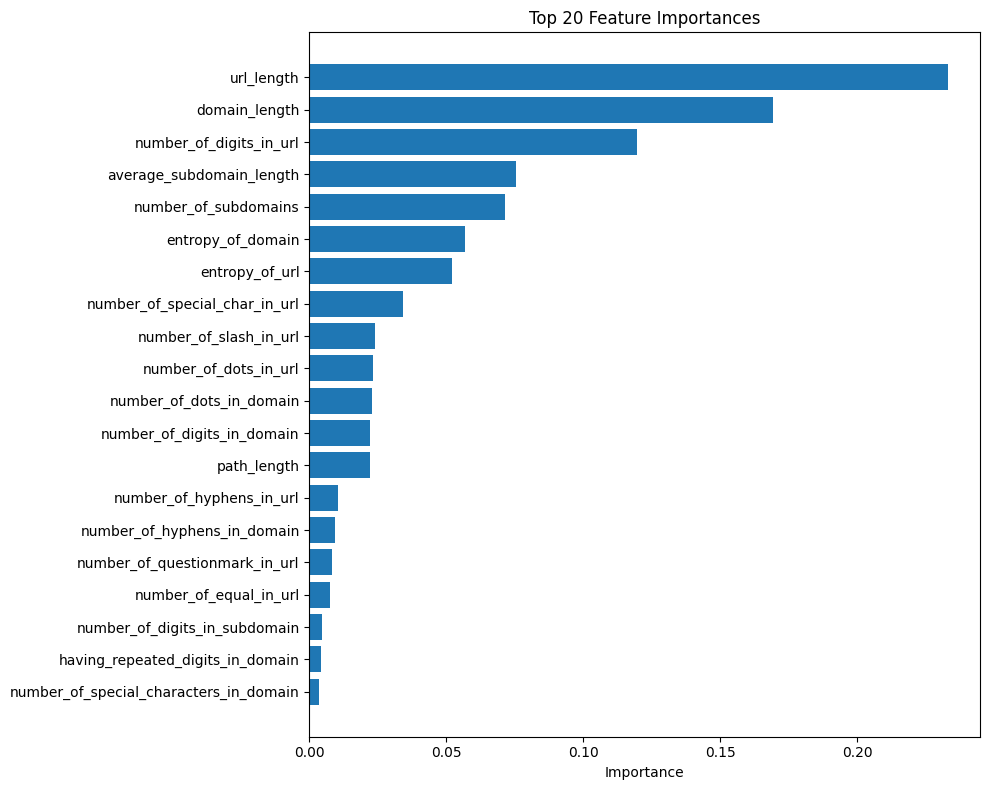

In [26]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': mendeley_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 20 Most Important Features:")
    print(feature_importance.head(20).to_string(index=False))
    
    # Optional: Visualize feature importance
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 8))
        top_features = feature_importance.head(20)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance')
        plt.title('Top 20 Feature Importances')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    except:
        print("(Matplotlib not available for visualization)")